<a href="https://www.kaggle.com/code/lalit7881/ai-impact-on-health-99?scriptVersionId=330306529" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/gauravjhaeigenvector/ai-impact-on-health/AI_Impact_on_Health_Dataset_5000_Enhanced.csv


## Loading dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/gauravjhaeigenvector/ai-impact-on-health/AI_Impact_on_Health_Dataset_5000_Enhanced.csv')

In [3]:
df.head()

,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,...,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
0,1,56,56-65,Female,No,22.2,Normal,Fitness Tracker,8,Medium,...,17,68,69,1,1.47,Improved,0.11,9,High,Low
1,2,69,66-79,Male,No,24.8,Normal,Fitness Tracker,8,Medium,...,19,51,63,12,23.53,Highly Improved,1.33,7,Medium,Low
2,3,46,46-55,Female,No,23.1,Normal,Mental Health App,8,Medium,...,12,57,72,15,26.32,Highly Improved,1.67,5,Medium,Low
3,4,32,26-35,Female,Yes,24.9,Normal,Fitness Tracker,16,High,...,17,83,99,16,19.28,Highly Improved,0.94,1,Low,Medium
4,5,60,56-65,Male,No,30.4,Obese,Fitness Tracker,11,Medium,...,12,41,39,-2,-4.88,Declined,-0.17,9,High,Medium


In [4]:
df.tail()

,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,...,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
4995,4996,42,36-45,Female,Yes,20.0,Normal,Fitness Tracker,19,High,...,19,57,58,1,1.75,Improved,0.05,10,High,Medium
4996,4997,39,36-45,Female,Yes,22.7,Normal,Diagnostic Assistant,16,High,...,20,52,57,5,9.62,Improved,0.29,5,Medium,Medium
4997,4998,48,46-55,Female,No,26.8,Overweight,Mental Health App,13,Medium,...,25,61,71,10,16.39,Improved,0.71,3,Low,Low
4998,4999,34,26-35,Female,Yes,27.9,Overweight,Telemedicine,13,Medium,...,15,53,72,19,35.85,Highly Improved,1.36,2,Low,Medium
4999,5000,72,66-79,Male,No,22.0,Normal,Diagnostic Assistant,2,Low,...,6,50,56,6,12.00,Improved,2.00,6,Medium,Low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Participant_ID                      5000 non-null   int64  
 1   Age                                 5000 non-null   int64  
 2   Age_Group                           5000 non-null   object 
 3   Gender                              5000 non-null   object 
 4   Chronic_Condition                   5000 non-null   object 
 5   BMI                                 5000 non-null   float64
 6   BMI_Category                        5000 non-null   object 
 7   AI_Tool_Type                        5000 non-null   object 
 8   AI_Health_App_Usage_Hours_Per_Week  5000 non-null   int64  
 9   AI_Usage_Level                      5000 non-null   object 
 10  Exercise_Hours_Per_Week             5000 non-null   int64  
 11  Exercise_Level                      5000 no

In [6]:
df.isnull()

,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,...,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

Participant_ID                        0
Age                                   0
Age_Group                             0
Gender                                0
Chronic_Condition                     0
BMI                                   0
BMI_Category                          0
AI_Tool_Type                          0
AI_Health_App_Usage_Hours_Per_Week    0
AI_Usage_Level                        0
Exercise_Hours_Per_Week               0
Exercise_Level                        0
Total_Engagement_Hours_Per_Week       0
Health_Score_Before_AI                0
Health_Score_After_AI                 0
Improvement                           0
Improvement_Percentage                0
Improvement_Category                  0
Improvement_Per_AI_Hour               0
Satisfaction_Score                    0
Satisfaction_Level                    0
Risk_Category                         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Participant_ID                          int64
Age                                     int64
Age_Group                              object
Gender                                 object
Chronic_Condition                      object
BMI                                   float64
BMI_Category                           object
AI_Tool_Type                           object
AI_Health_App_Usage_Hours_Per_Week      int64
AI_Usage_Level                         object
Exercise_Hours_Per_Week                 int64
Exercise_Level                         object
Total_Engagement_Hours_Per_Week         int64
Health_Score_Before_AI                  int64
Health_Score_After_AI                   int64
Improvement                             int64
Improvement_Percentage                float64
Improvement_Category                   object
Improvement_Per_AI_Hour               float64
Satisfaction_Score                      int64
Satisfaction_Level                     object
Risk_Category                     

In [10]:
df.shape

(5000, 22)

In [11]:
df.columns

Index(['Participant_ID', 'Age', 'Age_Group', 'Gender', 'Chronic_Condition',
       'BMI', 'BMI_Category', 'AI_Tool_Type',
       'AI_Health_App_Usage_Hours_Per_Week', 'AI_Usage_Level',
       'Exercise_Hours_Per_Week', 'Exercise_Level',
       'Total_Engagement_Hours_Per_Week', 'Health_Score_Before_AI',
       'Health_Score_After_AI', 'Improvement', 'Improvement_Percentage',
       'Improvement_Category', 'Improvement_Per_AI_Hour', 'Satisfaction_Score',
       'Satisfaction_Level', 'Risk_Category'],
      dtype='object')

In [12]:
df.nunique()

Participant_ID                        5000
Age                                     62
Age_Group                                6
Gender                                   3
Chronic_Condition                        2
BMI                                    238
BMI_Category                             4
AI_Tool_Type                             4
AI_Health_App_Usage_Hours_Per_Week      21
AI_Usage_Level                           3
Exercise_Hours_Per_Week                 15
Exercise_Level                           3
Total_Engagement_Hours_Per_Week         35
Health_Score_Before_AI                  50
Health_Score_After_AI                   66
Improvement                             26
Improvement_Percentage                 970
Improvement_Category                     4
Improvement_Per_AI_Hour                262
Satisfaction_Score                      10
Satisfaction_Level                       3
Risk_Category                            3
dtype: int64

## EDA

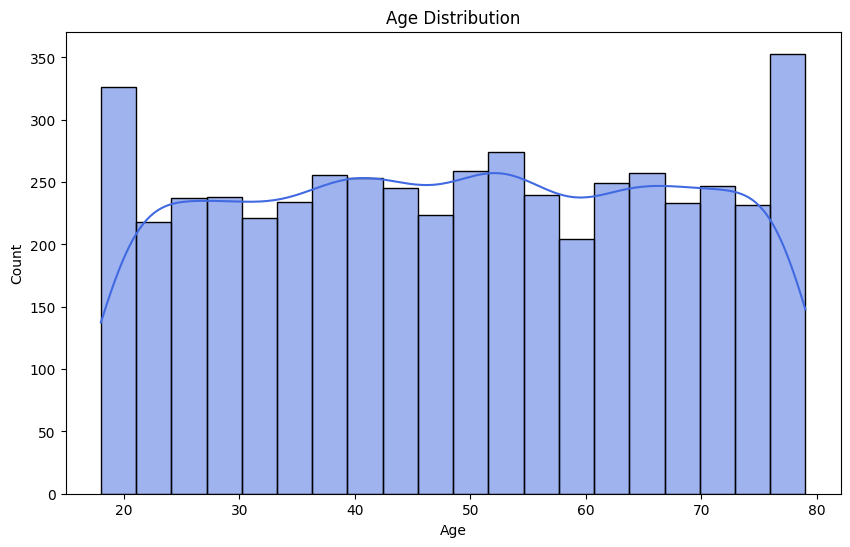

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, kde=True, color='royalblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

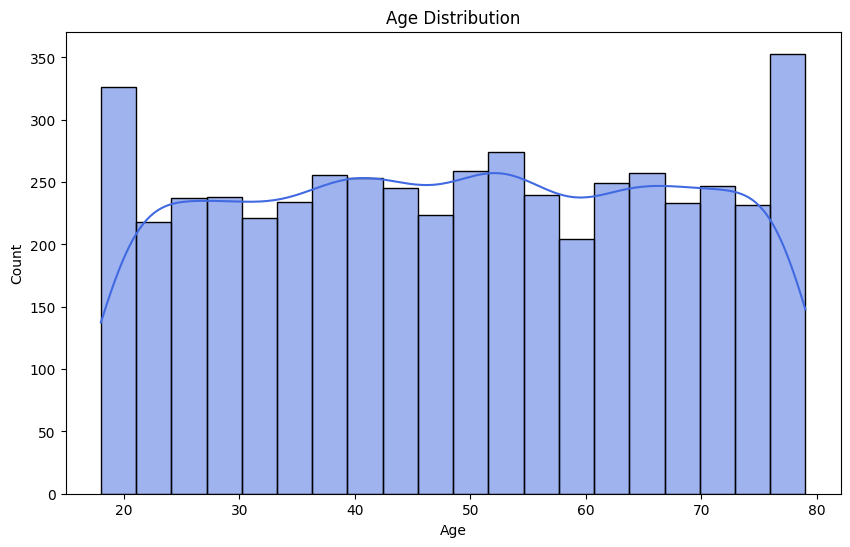

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, kde=True, color='royalblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

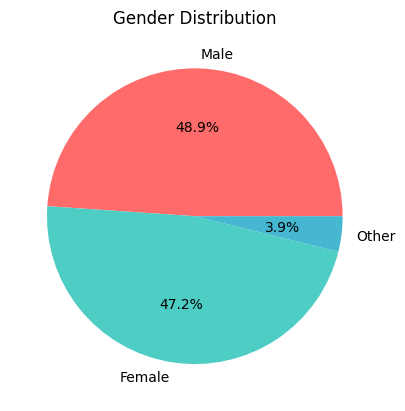

In [15]:
colors = ['#FF6B6B','#4ECDC4','#45B7D1']

df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors
)

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

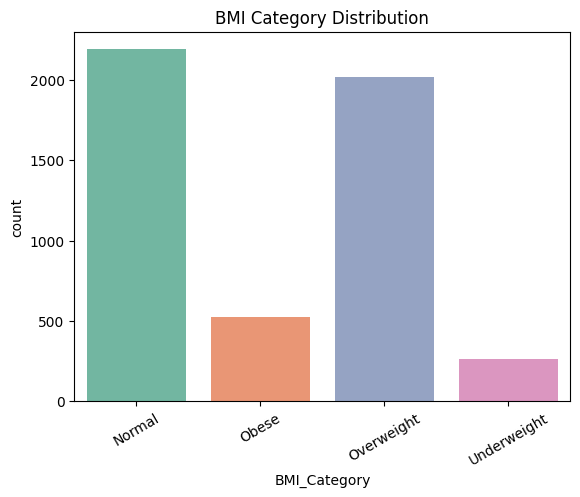

In [16]:
sns.countplot(
    data=df,
    x='BMI_Category',
    palette='Set2'
)

plt.title('BMI Category Distribution')
plt.xticks(rotation=30)
plt.show()

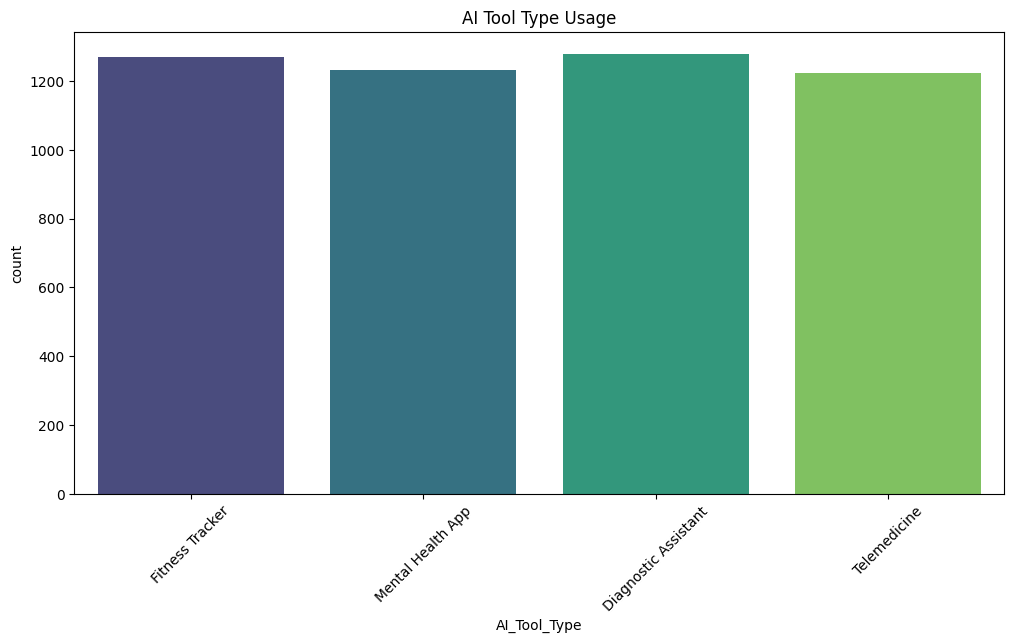

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='AI_Tool_Type',
    palette='viridis'
)

plt.title('AI Tool Type Usage')
plt.xticks(rotation=45)
plt.show()

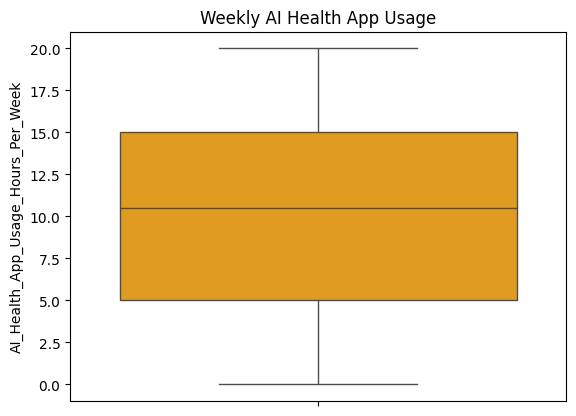

In [18]:
sns.boxplot(
    y=df['AI_Health_App_Usage_Hours_Per_Week'],
    color='orange'
)

plt.title('Weekly AI Health App Usage')
plt.show()

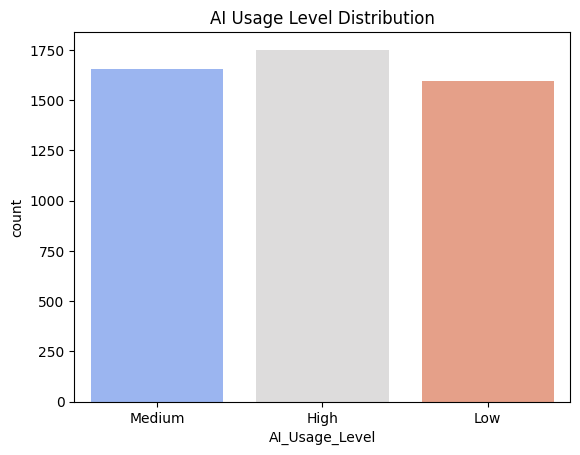

In [19]:
sns.countplot(
    data=df,
    x='AI_Usage_Level',
    palette='coolwarm'
)

plt.title('AI Usage Level Distribution')
plt.show()

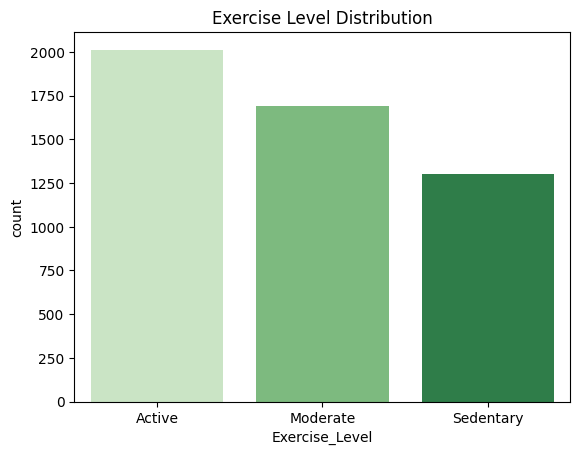

In [20]:
sns.countplot(
    data=df,
    x='Exercise_Level',
    palette='Greens'
)

plt.title('Exercise Level Distribution')
plt.show()

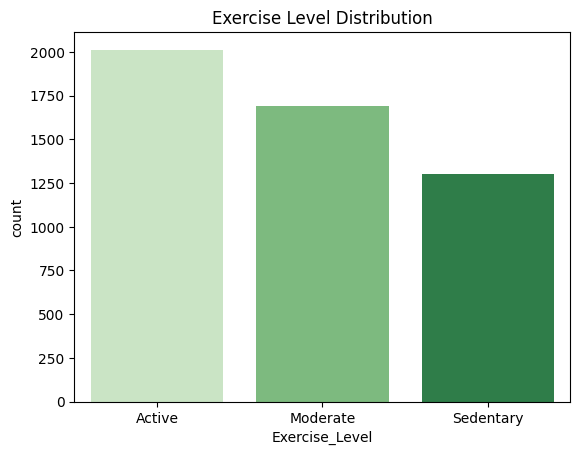

In [21]:
sns.countplot(
    data=df,
    x='Exercise_Level',
    palette='Greens'
)

plt.title('Exercise Level Distribution')
plt.show()

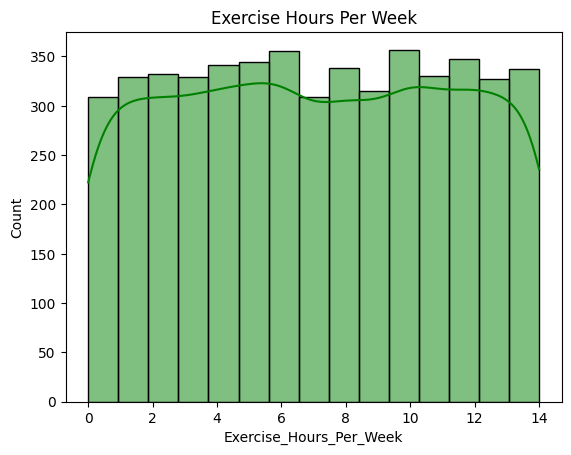

In [22]:
sns.histplot(
    df['Exercise_Hours_Per_Week'],
    bins=15,
    color='green',
    kde=True
)

plt.title('Exercise Hours Per Week')
plt.show()

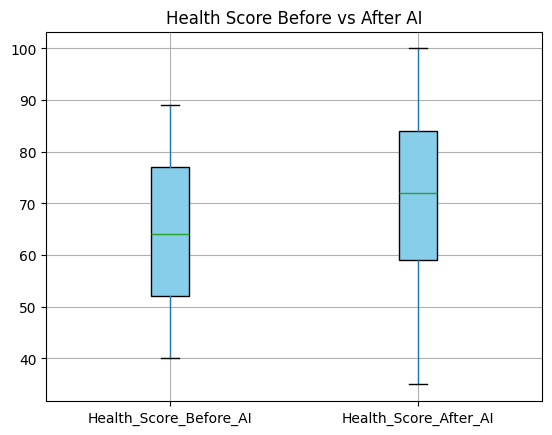

In [23]:
health_scores = df[['Health_Score_Before_AI',
                    'Health_Score_After_AI']]

health_scores.boxplot(
    patch_artist=True,
    boxprops=dict(facecolor='skyblue')
)

plt.title('Health Score Before vs After AI')
plt.show()

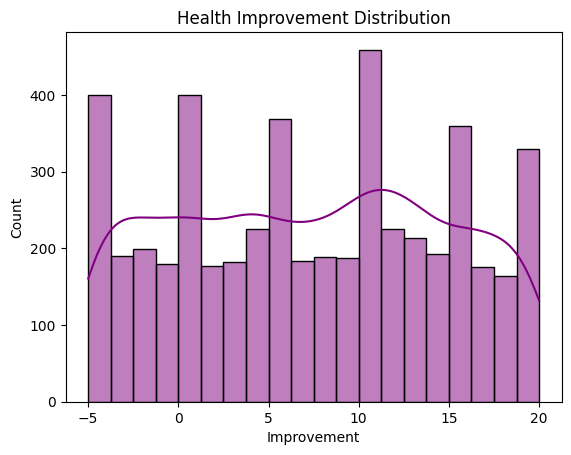

In [24]:
sns.histplot(
    df['Improvement'],
    bins=20,
    kde=True,
    color='purple'
)

plt.title('Health Improvement Distribution')
plt.show()

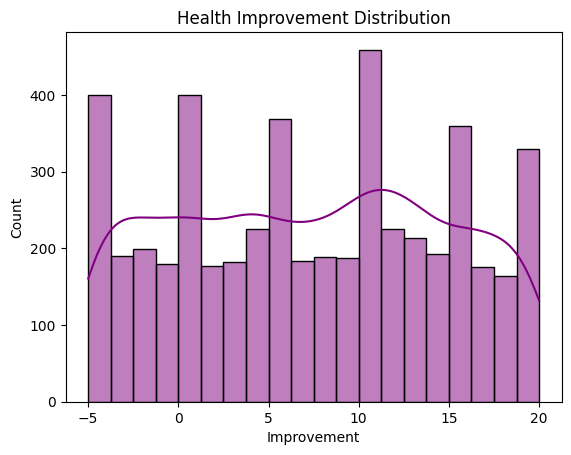

In [25]:
sns.histplot(
    df['Improvement'],
    bins=20,
    kde=True,
    color='purple'
)

plt.title('Health Improvement Distribution')
plt.show()

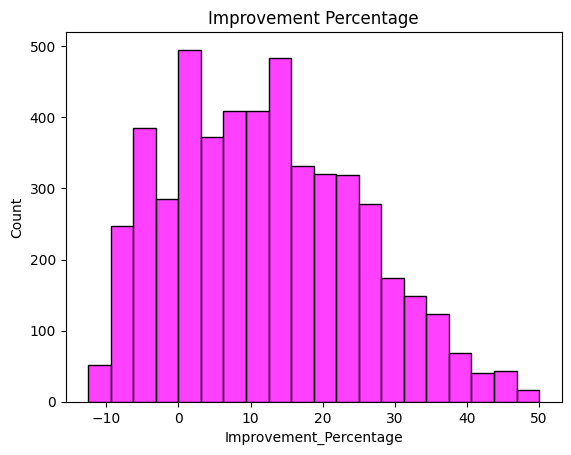

In [26]:
sns.histplot(
    df['Improvement_Percentage'],
    bins=20,
    color='magenta'
)

plt.title('Improvement Percentage')
plt.show()

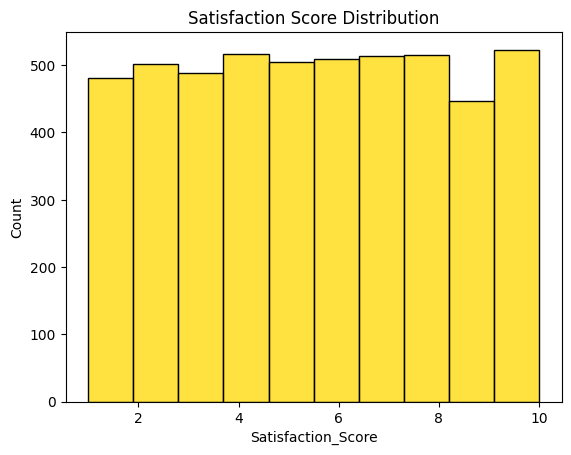

In [27]:
sns.histplot(
    df['Satisfaction_Score'],
    bins=10,
    color='gold'
)

plt.title('Satisfaction Score Distribution')
plt.show()

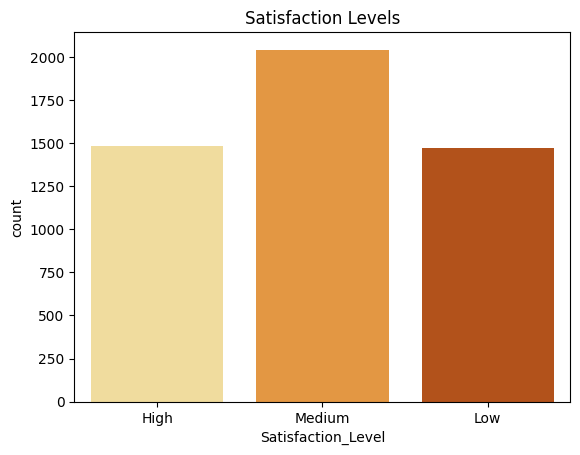

In [28]:
sns.countplot(
    data=df,
    x='Satisfaction_Level',
    palette='YlOrBr'
)

plt.title('Satisfaction Levels')
plt.show()

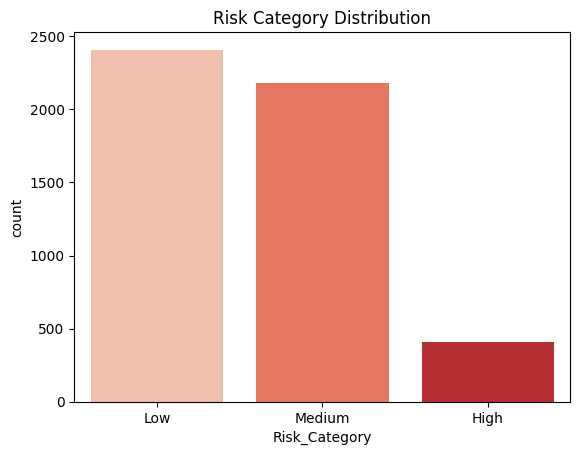

In [29]:
sns.countplot(
    data=df,
    x='Risk_Category',
    palette='Reds'
)

plt.title('Risk Category Distribution')
plt.show()

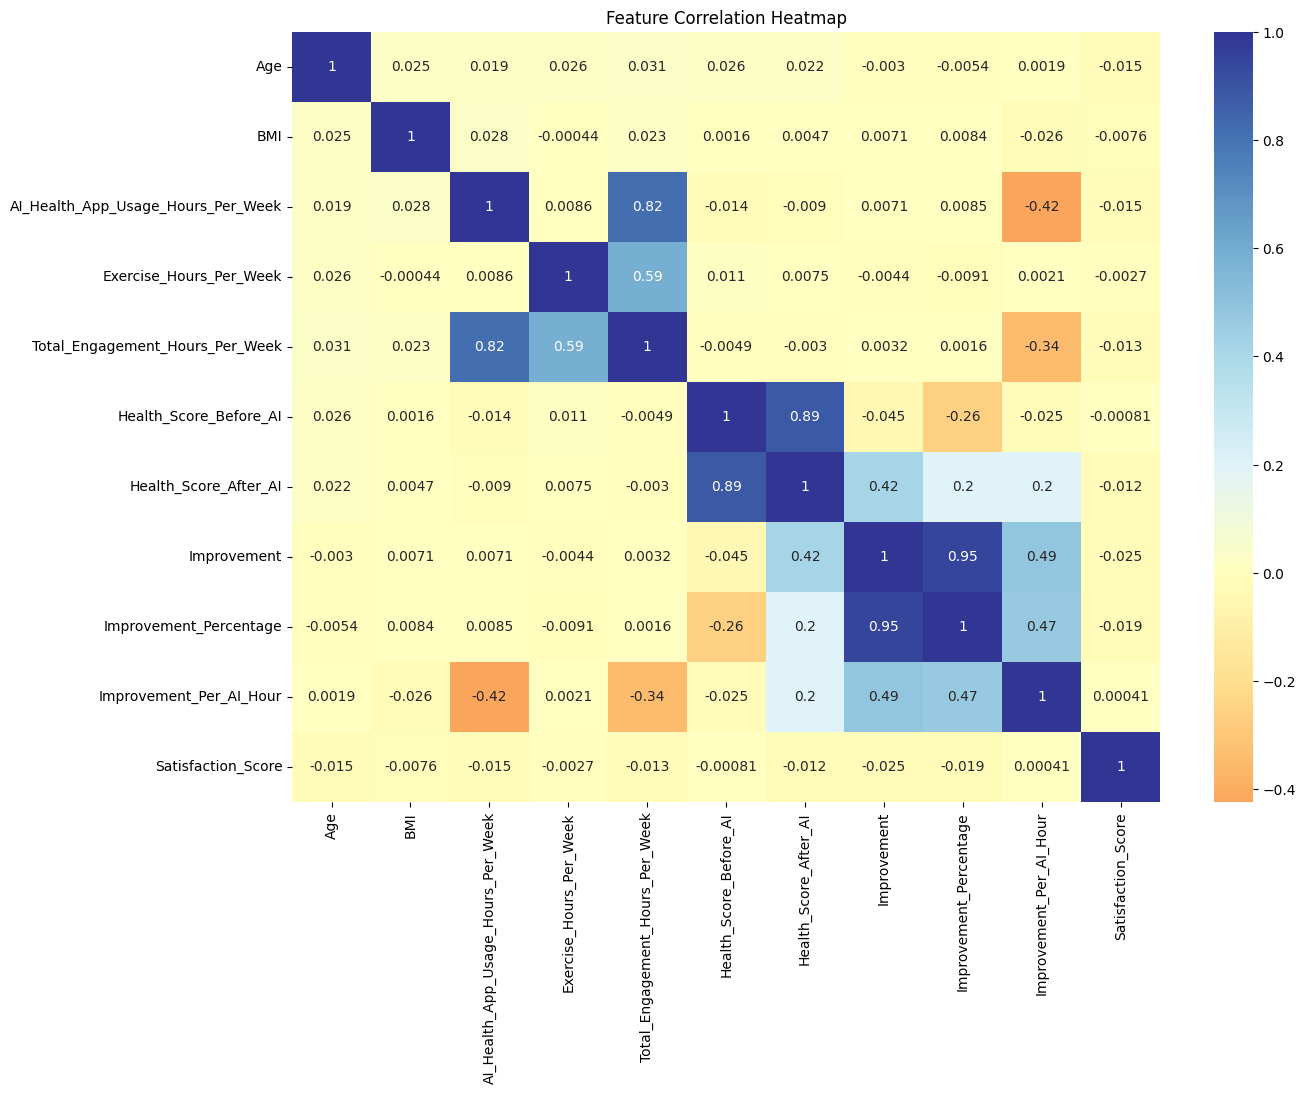

In [30]:
numerical_cols = [
    'Age',
    'BMI',
    'AI_Health_App_Usage_Hours_Per_Week',
    'Exercise_Hours_Per_Week',
    'Total_Engagement_Hours_Per_Week',
    'Health_Score_Before_AI',
    'Health_Score_After_AI',
    'Improvement',
    'Improvement_Percentage',
    'Improvement_Per_AI_Hour',
    'Satisfaction_Score'
]

corr = df[numerical_cols].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlBu',
    center=0
)

plt.title('Feature Correlation Heatmap')
plt.show()

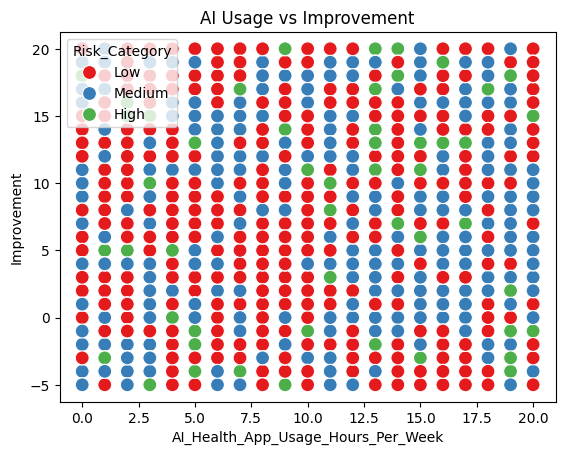

In [31]:
sns.scatterplot(
    data=df,
    x='AI_Health_App_Usage_Hours_Per_Week',
    y='Improvement',
    hue='Risk_Category',
    palette='Set1',
    s=100
)

plt.title('AI Usage vs Improvement')
plt.show()

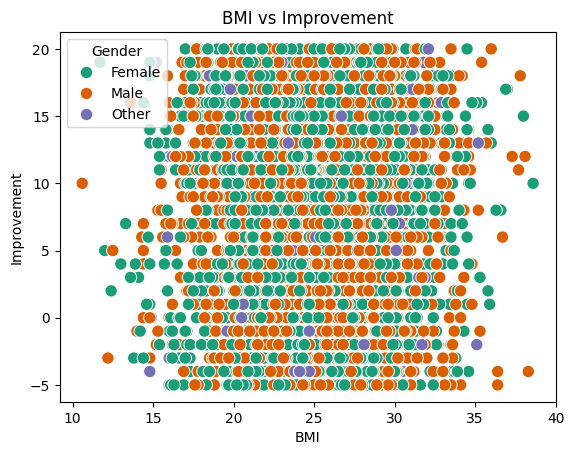

In [32]:
sns.scatterplot(
    data=df,
    x='BMI',
    y='Improvement',
    hue='Gender',
    palette='Dark2',
    s=80
)

plt.title('BMI vs Improvement')
plt.show()

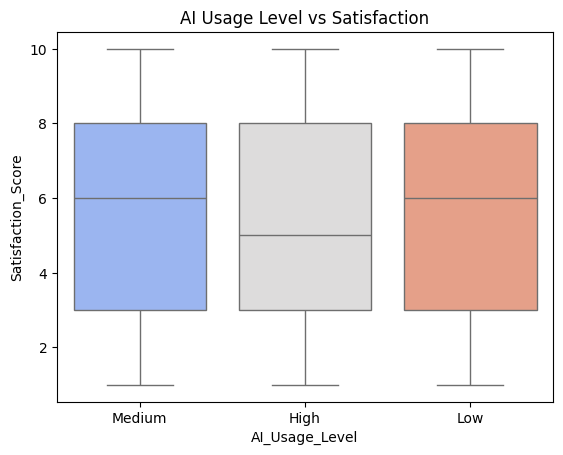

In [33]:
sns.boxplot(
    data=df,
    x='AI_Usage_Level',
    y='Satisfaction_Score',
    palette='coolwarm'
)

plt.title('AI Usage Level vs Satisfaction')
plt.show()

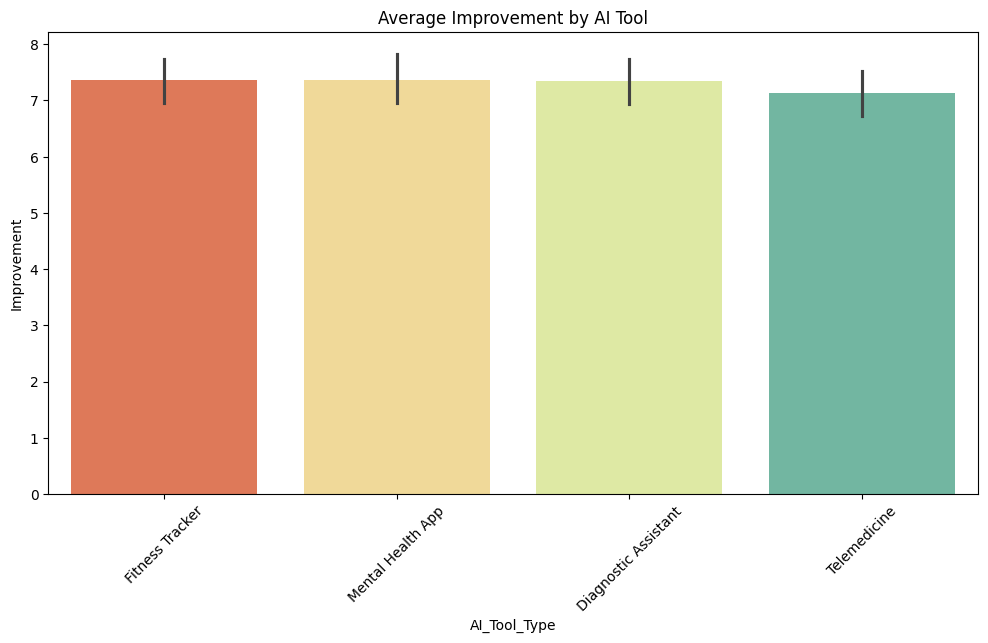

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='AI_Tool_Type',
    y='Improvement',
    palette='Spectral'
)

plt.title('Average Improvement by AI Tool')
plt.xticks(rotation=45)
plt.show()

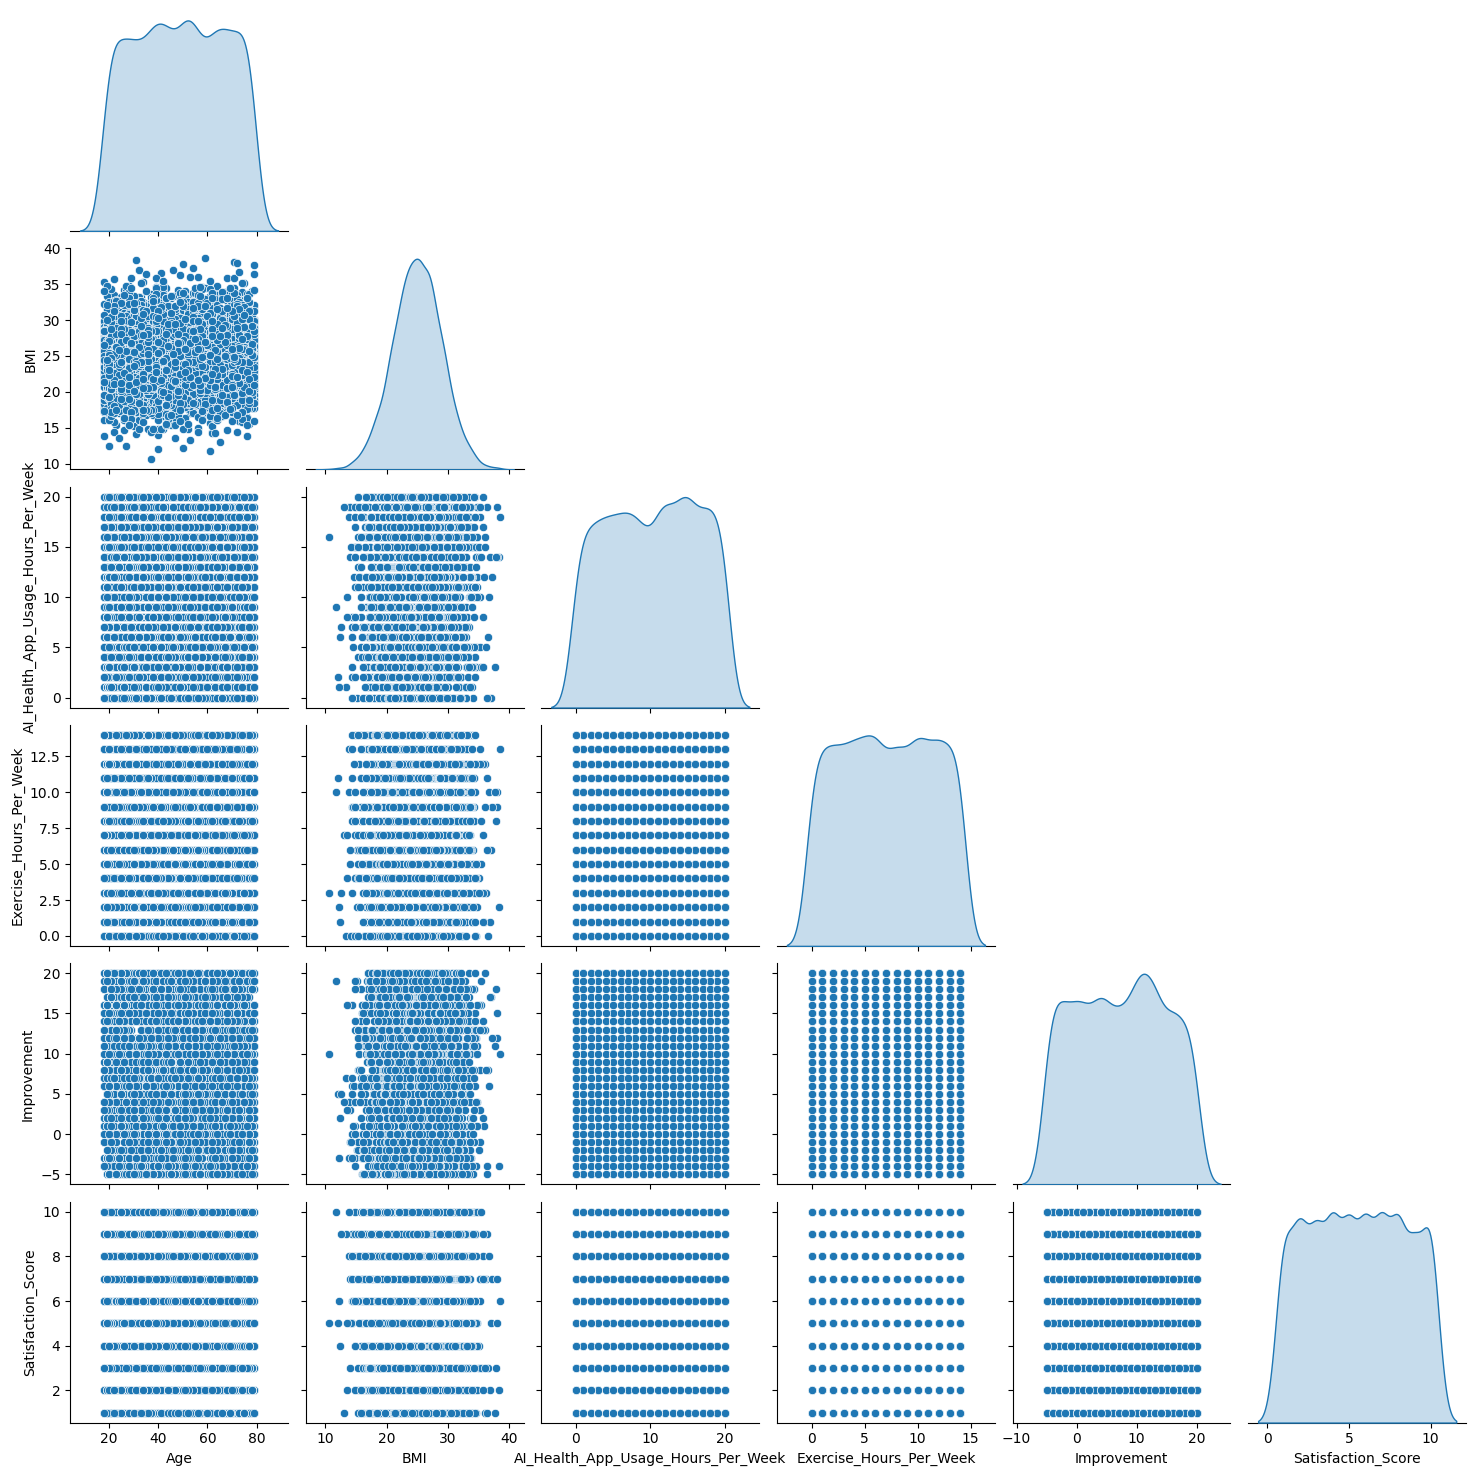

In [35]:
important_cols = [
    'Age',
    'BMI',
    'AI_Health_App_Usage_Hours_Per_Week',
    'Exercise_Hours_Per_Week',
    'Improvement',
    'Satisfaction_Score'
]

sns.pairplot(
    df[important_cols],
    corner=True,
    diag_kind='kde'
)

plt.show()

## Feature engineering

In [36]:
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [37]:
data = df.copy()

In [38]:
data = data.drop(columns=['Participant_ID'], errors='ignore')

In [39]:
target = 'Improvement_Category'

In [40]:
data = data.dropna(subset=[target])

In [41]:
X = data.drop(columns=[target])
y = data[target]

In [42]:
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [43]:
X = X.fillna(X.median(numeric_only=True))

In [44]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y.astype(str))

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
model = LogisticRegression(max_iter=2000)

In [48]:
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [49]:
y_pred = model.predict(X_test_scaled)

In [50]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.99


In [51]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))


Classification Report:
                 precision    recall  f1-score   support

       Declined       0.99      1.00      1.00       194
Highly Improved       1.00      1.00      1.00       378
       Improved       0.98      1.00      0.99       388
      No Change       1.00      0.75      0.86        40

       accuracy                           0.99      1000
      macro avg       0.99      0.94      0.96      1000
   weighted avg       0.99      0.99      0.99      1000



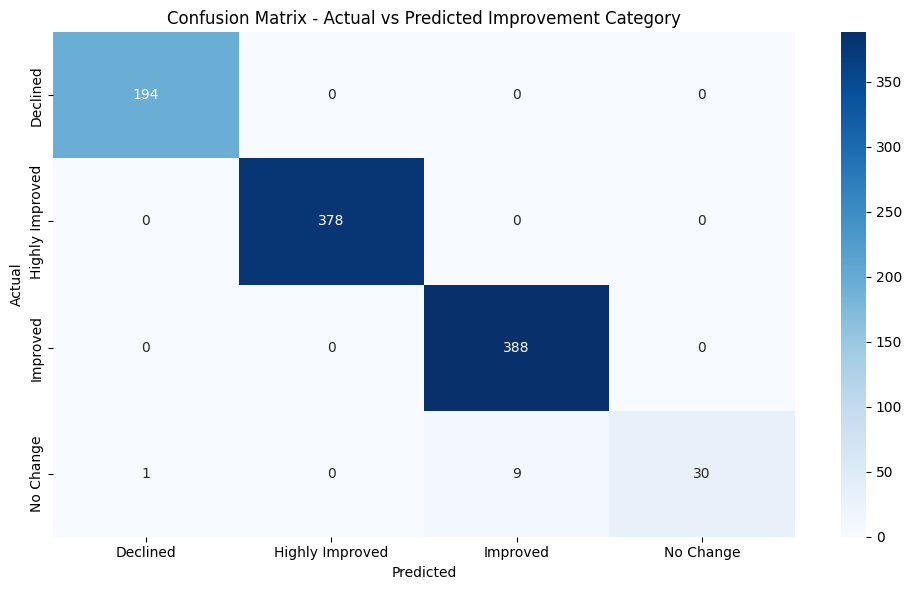

In [52]:
cm = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Actual vs Predicted Improvement Category")
plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!!!!!!!!!